[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter5_seminar_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 5: Bayesian VAR, factor models and nowcasting

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 5; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_5'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Data, BVAR, factor and nowcasting tools of Chapter 5 and the functions of the solved tasks.

In [ ]:
import hashlib
from scipy import linalg, special
SEED = 2026
FRED_MD_URL = 'https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv'
END_M = '2026-07-01'
FRED_SPEC = [('RPI', 'RPI', 5, 1), ('W875RX1', 'W875RX1', 5, 1), ('INDPRO', 'INDPRO', 5, 1), ('IPFPNSS', 'IPFPNSS', 5, 1), ('IPFINAL', 'IPFINAL', 5, 1), ('IPCONGD', 'IPCONGD', 5, 1), ('IPDCONGD', 'IPDCONGD', 5, 1), ('IPNCONGD', 'IPNCONGD', 5, 1), ('IPBUSEQ', 'IPBUSEQ', 5, 1), ('IPMAT', 'IPMAT', 5, 1), ('IPDMAT', 'IPDMAT', 5, 1), ('IPNMAT', 'IPNMAT', 5, 1), ('IPMANSICS', 'IPMANSICS', 5, 1), ('IPB51222S', 'IPB51222S', 5, 1), ('IPFUELS', 'IPFUELS', 5, 1), ('CUMFNS', 'CUMFNS', 2, 1), ('CLF16OV', 'CLF16OV', 5, 2), ('CE16OV', 'CE16OV', 5, 2), ('UNRATE', 'UNRATE', 2, 2), ('UEMPMEAN', 'UEMPMEAN', 2, 2), ('UEMPLT5', 'UEMPLT5', 5, 2), ('UEMP5TO14', 'UEMP5TO14', 5, 2), ('UEMP15OV', 'UEMP15OV', 5, 2), ('UEMP15T26', 'UEMP15T26', 5, 2), ('UEMP27OV', 'UEMP27OV', 5, 2), ('PAYEMS', 'PAYEMS', 5, 2), ('USPRIV', 'USPRIV', 5, 2), ('USGOOD', 'USGOOD', 5, 2), ('CES1021000001', 'CES1021000001', 5, 2), ('USCONS', 'USCONS', 5, 2), ('MANEMP', 'MANEMP', 5, 2), ('DMANEMP', 'DMANEMP', 5, 2), ('NDMANEMP', 'NDMANEMP', 5, 2), ('SRVPRD', 'SRVPRD', 5, 2), ('USTPU', 'USTPU', 5, 2), ('USWTRADE', 'USWTRADE', 5, 2), ('USTRADE', 'USTRADE', 5, 2), ('USFIRE', 'USFIRE', 5, 2), ('USGOVT', 'USGOVT', 5, 2), ('CES0600000007', 'CES0600000007', 1, 2), ('AWOTMAN', 'AWOTMAN', 2, 2), ('AWHMAN', 'AWHMAN', 1, 2), ('CES0600000008', 'CES0600000008', 6, 2), ('CES2000000008', 'CES2000000008', 6, 2), ('CES3000000008', 'CES3000000008', 6, 2), ('HOUST', 'HOUST', 4, 3), ('HOUSTNE', 'HOUSTNE', 4, 3), ('HOUSTMW', 'HOUSTMW', 4, 3), ('HOUSTS', 'HOUSTS', 4, 3), ('HOUSTW', 'HOUSTW', 4, 3), ('PERMIT', 'PERMIT', 4, 3), ('PERMITNE', 'PERMITNE', 4, 3), ('PERMITMW', 'PERMITMW', 4, 3), ('PERMITS', 'PERMITS', 4, 3), ('PERMITW', 'PERMITW', 4, 3), ('DPCERA3M086SBEA', 'DPCERA3M086SBEA', 5, 4), ('CMRMTSPL', 'CMRMTSPLx', 5, 4), ('RRSFS', 'RETAILx', 5, 4), ('ACOGNO', 'ACOGNO', 5, 4), ('ANDENO', 'ANDENOx', 5, 4), ('AMDMUO', 'AMDMUOx', 5, 4), ('BUSINV', 'BUSINVx', 5, 4), ('ISRATIO', 'ISRATIOx', 2, 4), ('UMCSENT', 'UMCSENTx', 2, 4), ('M1SL', 'M1SL', 6, 5), ('M2SL', 'M2SL', 6, 5), ('M2REAL', 'M2REAL', 5, 5), ('BOGMBASE', 'BOGMBASE', 6, 5), ('TOTRESNS', 'TOTRESNS', 6, 5), ('NONBORRES', 'NONBORRES', 7, 5), ('BUSLOANS', 'BUSLOANS', 6, 5), ('REALLN', 'REALLN', 6, 5), ('NONREVSL', 'NONREVSL', 6, 5), ('DTCOLNVHFNM', 'DTCOLNVHFNM', 6, 5), ('DTCTHFNM', 'DTCTHFNM', 6, 5), ('INVEST', 'INVEST', 6, 5), ('FEDFUNDS', 'FEDFUNDS', 2, 6), ('CPF3M', 'CP3Mx', 2, 6), ('TB3MS', 'TB3MS', 2, 6), ('TB6MS', 'TB6MS', 2, 6), ('GS1', 'GS1', 2, 6), ('GS5', 'GS5', 2, 6), ('GS10', 'GS10', 2, 6), ('AAA', 'AAA', 2, 6), ('BAA', 'BAA', 2, 6), ('EXSZUS', 'EXSZUSx', 5, 6), ('EXJPUS', 'EXJPUSx', 5, 6), ('EXUSUK', 'EXUSUKx', 5, 6), ('EXCAUS', 'EXCAUSx', 5, 6), ('WPSFD49207', 'WPSFD49207', 6, 7), ('WPSFD49502', 'WPSFD49502', 6, 7), ('WPSID61', 'WPSID61', 6, 7), ('WPSID62', 'WPSID62', 6, 7), ('WTISPLC', 'OILPRICEx', 6, 7), ('PPICMM', 'PPICMM', 6, 7), ('CPIAUCSL', 'CPIAUCSL', 6, 7), ('CPIAPPSL', 'CPIAPPSL', 6, 7), ('CPITRNSL', 'CPITRNSL', 6, 7), ('CPIMEDSL', 'CPIMEDSL', 6, 7), ('CUSR0000SAC', 'CUSR0000SAC', 6, 7), ('CUSR0000SAD', 'CUSR0000SAD', 6, 7), ('CUSR0000SAS', 'CUSR0000SAS', 6, 7), ('CPIULFSL', 'CPIULFSL', 6, 7), ('CUSR0000SA0L2', 'CUSR0000SA0L2', 6, 7), ('CUSR0000SA0L5', 'CUSR0000SA0L5', 6, 7), ('PCEPI', 'PCEPI', 6, 7), ('DDURRG3M086SBEA', 'DDURRG3M086SBEA', 6, 7), ('DNDGRG3M086SBEA', 'DNDGRG3M086SBEA', 6, 7), ('DSERRG3M086SBEA', 'DSERRG3M086SBEA', 6, 7)]
SPREADS = [('COMPAPFF', 'CPF3M'), ('TB3SMFFM', 'TB3MS'), ('TB6SMFFM', 'TB6MS'), ('T1YFFM', 'GS1'), ('T5YFFM', 'GS5'), ('T10YFFM', 'GS10'), ('AAAFFM', 'AAA'), ('BAAFFM', 'BAA')]
TCODE = {'RPI': 5, 'W875RX1': 5, 'INDPRO': 5, 'IPFPNSS': 5, 'IPFINAL': 5, 'IPCONGD': 5, 'IPDCONGD': 5, 'IPNCONGD': 5, 'IPBUSEQ': 5, 'IPMAT': 5, 'IPDMAT': 5, 'IPNMAT': 5, 'IPMANSICS': 5, 'IPB51222S': 5, 'IPFUELS': 5, 'CUMFNS': 2, 'CLF16OV': 5, 'CE16OV': 5, 'UNRATE': 2, 'UEMPMEAN': 2, 'UEMPLT5': 5, 'UEMP5TO14': 5, 'UEMP15OV': 5, 'UEMP15T26': 5, 'UEMP27OV': 5, 'PAYEMS': 5, 'USPRIV': 5, 'USGOOD': 5, 'CES1021000001': 5, 'USCONS': 5, 'MANEMP': 5, 'DMANEMP': 5, 'NDMANEMP': 5, 'SRVPRD': 5, 'USTPU': 5, 'USWTRADE': 5, 'USTRADE': 5, 'USFIRE': 5, 'USGOVT': 5, 'CES0600000007': 1, 'AWOTMAN': 2, 'AWHMAN': 1, 'CES0600000008': 6, 'CES2000000008': 6, 'CES3000000008': 6, 'HOUST': 4, 'HOUSTNE': 4, 'HOUSTMW': 4, 'HOUSTS': 4, 'HOUSTW': 4, 'PERMIT': 4, 'PERMITNE': 4, 'PERMITMW': 4, 'PERMITS': 4, 'PERMITW': 4, 'DPCERA3M086SBEA': 5, 'CMRMTSPL': 5, 'RRSFS': 5, 'ACOGNO': 5, 'ANDENO': 5, 'AMDMUO': 5, 'BUSINV': 5, 'ISRATIO': 2, 'UMCSENT': 2, 'M1SL': 6, 'M2SL': 6, 'M2REAL': 5, 'BOGMBASE': 6, 'TOTRESNS': 6, 'NONBORRES': 7, 'BUSLOANS': 6, 'REALLN': 6, 'NONREVSL': 6, 'DTCOLNVHFNM': 6, 'DTCTHFNM': 6, 'INVEST': 6, 'FEDFUNDS': 2, 'CPF3M': 2, 'TB3MS': 2, 'TB6MS': 2, 'GS1': 2, 'GS5': 2, 'GS10': 2, 'AAA': 2, 'BAA': 2, 'EXSZUS': 5, 'EXJPUS': 5, 'EXUSUK': 5, 'EXCAUS': 5, 'WPSFD49207': 6, 'WPSFD49502': 6, 'WPSID61': 6, 'WPSID62': 6, 'WTISPLC': 6, 'PPICMM': 6, 'CPIAUCSL': 6, 'CPIAPPSL': 6, 'CPITRNSL': 6, 'CPIMEDSL': 6, 'CUSR0000SAC': 6, 'CUSR0000SAD': 6, 'CUSR0000SAS': 6, 'CPIULFSL': 6, 'CUSR0000SA0L2': 6, 'CUSR0000SA0L5': 6, 'PCEPI': 6, 'DDURRG3M086SBEA': 6, 'DNDGRG3M086SBEA': 6, 'DSERRG3M086SBEA': 6, 'COMPAPFF': 1, 'TB3SMFFM': 1, 'TB6SMFFM': 1, 'T1YFFM': 1, 'T5YFFM': 1, 'T10YFFM': 1, 'AAAFFM': 1, 'BAAFFM': 1}
GROUP = {'RPI': 1, 'W875RX1': 1, 'INDPRO': 1, 'IPFPNSS': 1, 'IPFINAL': 1, 'IPCONGD': 1, 'IPDCONGD': 1, 'IPNCONGD': 1, 'IPBUSEQ': 1, 'IPMAT': 1, 'IPDMAT': 1, 'IPNMAT': 1, 'IPMANSICS': 1, 'IPB51222S': 1, 'IPFUELS': 1, 'CUMFNS': 1, 'CLF16OV': 2, 'CE16OV': 2, 'UNRATE': 2, 'UEMPMEAN': 2, 'UEMPLT5': 2, 'UEMP5TO14': 2, 'UEMP15OV': 2, 'UEMP15T26': 2, 'UEMP27OV': 2, 'PAYEMS': 2, 'USPRIV': 2, 'USGOOD': 2, 'CES1021000001': 2, 'USCONS': 2, 'MANEMP': 2, 'DMANEMP': 2, 'NDMANEMP': 2, 'SRVPRD': 2, 'USTPU': 2, 'USWTRADE': 2, 'USTRADE': 2, 'USFIRE': 2, 'USGOVT': 2, 'CES0600000007': 2, 'AWOTMAN': 2, 'AWHMAN': 2, 'CES0600000008': 2, 'CES2000000008': 2, 'CES3000000008': 2, 'HOUST': 3, 'HOUSTNE': 3, 'HOUSTMW': 3, 'HOUSTS': 3, 'HOUSTW': 3, 'PERMIT': 3, 'PERMITNE': 3, 'PERMITMW': 3, 'PERMITS': 3, 'PERMITW': 3, 'DPCERA3M086SBEA': 4, 'CMRMTSPL': 4, 'RRSFS': 4, 'ACOGNO': 4, 'ANDENO': 4, 'AMDMUO': 4, 'BUSINV': 4, 'ISRATIO': 4, 'UMCSENT': 4, 'M1SL': 5, 'M2SL': 5, 'M2REAL': 5, 'BOGMBASE': 5, 'TOTRESNS': 5, 'NONBORRES': 5, 'BUSLOANS': 5, 'REALLN': 5, 'NONREVSL': 5, 'DTCOLNVHFNM': 5, 'DTCTHFNM': 5, 'INVEST': 5, 'FEDFUNDS': 6, 'CPF3M': 6, 'TB3MS': 6, 'TB6MS': 6, 'GS1': 6, 'GS5': 6, 'GS10': 6, 'AAA': 6, 'BAA': 6, 'EXSZUS': 6, 'EXJPUS': 6, 'EXUSUK': 6, 'EXCAUS': 6, 'WPSFD49207': 7, 'WPSFD49502': 7, 'WPSID61': 7, 'WPSID62': 7, 'WTISPLC': 7, 'PPICMM': 7, 'CPIAUCSL': 7, 'CPIAPPSL': 7, 'CPITRNSL': 7, 'CPIMEDSL': 7, 'CUSR0000SAC': 7, 'CUSR0000SAD': 7, 'CUSR0000SAS': 7, 'CPIULFSL': 7, 'CUSR0000SA0L2': 7, 'CUSR0000SA0L5': 7, 'PCEPI': 7, 'DDURRG3M086SBEA': 7, 'DNDGRG3M086SBEA': 7, 'DSERRG3M086SBEA': 7, 'COMPAPFF': 6, 'TB3SMFFM': 6, 'TB6SMFFM': 6, 'T1YFFM': 6, 'T5YFFM': 6, 'T10YFFM': 6, 'AAAFFM': 6, 'BAAFFM': 6}
GROUPS = {1: 'Output and income', 2: 'Labour market', 3: 'Housing', 4: 'Consumption, orders, inventories', 5: 'Money and credit', 6: 'Interest and exchange rates', 7: 'Prices'}
SMALL = ['USPRIV', 'CPIAUCSL', 'FEDFUNDS']
MEDIUM = ['USPRIV', 'CPIAUCSL', 'FEDFUNDS', 'PPICMM', 'TOTRESNS', 'M2SL', 'W875RX1', 'DPCERA3M086SBEA', 'INDPRO', 'CUMFNS', 'UNRATE', 'HOUST', 'WPSFD49207', 'PCEPI', 'CES0600000008', 'M1SL', 'GS10', 'BAA', 'TB3MS', 'PERMIT']
FAST_GROUPS = (5, 6)
BGR = {'p': 13, 'window': 120, 'start': '1960-01-01', 'train_end': '1969-12-01', 'H': 12, 'eval1': ('1971-01-01', '2003-12-01'), 'eval2': ('2004-01-01', '2026-07-01'), 'irf': ('1961-01-01', '2002-12-01'), 'Hirf': 48}
GLP = {'lam': (0.2, 0.4), 'mu': (1.0, 1.0), 'dio': (1.0, 1.0)}
SW = {'H': (1, 6, 12), 'kmax': 12, 'pmax': 5, 'start': '1970-01-01', 'eval1': ('1970-01-01', '1998-12-01'), 'eval2': ('1999-01-01', '2026-07-01'), 'targets': ('INDPRO', 'PAYEMS', 'CPIAUCSL')}
BBE = {'K': 3, 'p': 13, 'start': '1960-01-01', 'end': '2001-08-01', 'end2': '2007-12-01', 'H': 48, 'B': 300}
RO_SPEC = {'ip': (('sts_inpr_m', 'M.PRD.B-D.SCA.I21.RO'), 2, 'dlog', 'Industrial production'), 'retail': (('sts_trtu_m', 'M.VOL_SLS.G47.SCA.I21.RO'), 2, 'dlog', 'Retail trade volume'), 'constr': (('sts_copr_m', 'M.PRD.F.SCA.I21.RO'), 2, 'dlog', 'Construction output'), 'ip_ea': (('sts_inpr_m', 'M.PRD.B-D.SCA.I21.EA20'), 2, 'dlog', 'Euro-area industrial production'), 'unemp': (('une_rt_m', 'M.SA.TOTAL.PC_ACT.T.RO'), 1, 'diff', 'Unemployment rate'), 'esi': (('ei_bssi_m_r2', 'M.BS-ESI-I.SA.RO'), 0, 'level', 'Economic sentiment indicator'), 'ici': (('ei_bssi_m_r2', 'M.BS-ICI-BAL.SA.RO'), 0, 'level', 'Industry confidence'), 'sci': (('ei_bssi_m_r2', 'M.BS-SCI-BAL.SA.RO'), 0, 'level', 'Services confidence'), 'rci': (('ei_bssi_m_r2', 'M.BS-RCI-BAL.SA.RO'), 0, 'level', 'Retail confidence'), 'bci': (('ei_bssi_m_r2', 'M.BS-CCI-BAL.SA.RO'), 0, 'level', 'Construction confidence'), 'cci': (('ei_bssi_m_r2', 'M.BS-CSMCI-BAL.SA.RO'), 0, 'level', 'Consumer confidence')}
RO_GDP = ('namq_10_gdp', 'Q.CLV20_MEUR.SCA.B1GQ.RO')
RO = {'start': '2003-01-01', 'eval': ('2013-03-01', '2026-06-01'), 'eval_long': ('2010-03-01', '2026-06-01'), 'r': 2, 'covid': ('2020-04-01', '2020-07-01'), 'gdp_lag': 2, 'vintages': ('M1', 'M2', 'M3', 'M+1'), 'K': 6, 'target': '2026-07-01', 'news_old': '2026-08-01', 'news_new': '2026-09-01'}
MM = np.array([1, 2, 3, 2, 1]) / 3.0
BRIDGE = ('ip', 'retail', 'esi')
MIDAS_X = ('ip', 'esi')
FAVAR_SHOW = [('FEDFUNDS', 'Federal funds rate'), ('INDPRO', 'Industrial production'), ('CPIAUCSL', 'CPI'), ('UNRATE', 'Unemployment rate'), ('CUMFNS', 'Capacity utilisation'), ('DPCERA3M086SBEA', 'Real consumption'), ('HOUST', 'Housing starts'), ('M2SL', 'M2'), ('PAYEMS', 'Payroll employment')]
_FILES = {}
A1 = {'sxx': 50.0, 'sxy': 40.0, 's2': 1.0, 'm0': 1.0, 's0': 0.2}
A2 = {'lam': 0.2, 'sig': (1.0, 2.0), 'XX': [[100.0, 20.0], [20.0, 400.0]], 'Xy': [85.0, 30.0], 's2': 1.0}
A3 = {'M': 10000, 'rho': 0.9, 'means': [0.1, 0.12, 0.35, 0.11], 'W': 0.01, 'n': 1000}
A4 = {'lam': 0.2, 'sig': 1.0, 'delta': 1.0, 'ybar': 5.0, 'mu': 1.0}
A5 = {'N': 3, 'rho': 0.6}
A6 = {'N': 100, 'T': 200, 'V': [1.0, 0.62, 0.48, 0.43, 0.415, 0.405]}
A7 = {'x': [0.4, 0.3, -0.1, 0.5, 0.2]}
A8 = {'cyx': 0.6, 'xhat': 0.2, 'x': -0.8, 'C': [[1.0, 0.5], [0.5, 1.0]], 'cy': [0.6, 0.3], 'news': [-1.0, 0.4], 'theta': (0.5, -0.2), 'K': 4}
RO_BVAR = {'start': '2005-08-01', 'end': '2026-07-01', 'p': 12, 'eval': ('2015-01-01', '2025-07-01')}


def cached(key, fn):
    """Run fn() once; with the environment variable ATS_CACHE, keep a local copy between runs."""
    if key in _FILES:
        return _FILES[key]
    d = os.environ.get('ATS_CACHE')
    path = os.path.join(d, 'ch5_' + hashlib.md5(key.encode()).hexdigest() + '.pkl') if d else None
    if path and os.path.exists(path):
        _FILES[key] = pd.read_pickle(path)
        return _FILES[key]
    x = fn()
    if path:
        os.makedirs(d, exist_ok=True)
        pd.to_pickle(x, path)
    _FILES[key] = x
    return x


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def fred_md_raw():
    """Raw monthly levels of the FRED-MD series distributed by FRED (one public CSV per series), 1959 onward,
    with the FRED-MD spreads (rate minus the federal funds rate)."""
    def get():
        d = pd.concat([read_fred(s[0]) for s in FRED_SPEC], axis=1)
        d.index = pd.to_datetime(d.index)
        return d.resample('MS').mean().loc['1959-01-01':]
    d = cached('fred_md_raw', get).copy()
    # October 2025: the household survey and the CPI were not collected (US federal shutdown); an isolated missing
    # month inside a series is filled by linear interpolation
    gap = d.isna() & d.shift(1).notna() & d.shift(-1).notna()
    d = d.where(~gap, (d.shift(1) + d.shift(-1)) / 2)
    for name, rate in SPREADS:
        d[name] = d[rate] - d['FEDFUNDS']
    return d


def fred_md_official(url=FRED_MD_URL):
    """The official FRED-MD file (McCracken and Ng 2016), when the St. Louis Fed server allows the download:
    returns (data, transformation codes) or None."""
    try:
        t = pd.read_csv(url, storage_options={'User-Agent': 'Mozilla/5.0'})
    except Exception:
        return None
    tc = t.iloc[0, 1:].astype(int)
    d = t.iloc[1:].dropna(how='all')
    d.index = pd.to_datetime(d.iloc[:, 0], format='%m/%d/%Y')
    return d.iloc[:, 1:].astype(float), tc


def transform(x, tc):
    """FRED-MD transformation codes: 1 level, 2 first difference, 3 second difference, 4 log, 5 log difference,
    6 second log difference, 7 first difference of the percent change."""
    x = pd.Series(x, dtype=float)
    if tc in (4, 5, 6):
        x = np.log(x.where(x > 0))
    if tc == 1 or tc == 4:
        return x
    if tc in (2, 5):
        return x.diff()
    if tc in (3, 6):
        return x.diff().diff()
    if tc == 7:
        return (x / x.shift(1) - 1).diff()
    raise ValueError(tc)


def remove_outliers(X):
    """McCracken and Ng (2016): an observation further than 10 interquartile ranges from the median is missing."""
    med, q1, q3 = X.median(), X.quantile(0.25), X.quantile(0.75)
    return X.where((X - med).abs() <= 10 * (q3 - q1))


def fred_md_panel(raw=None, start='1960-01-01', end=END_M):
    """Stationary FRED-MD-style panel: transformed series, outliers removed (missing values left for the EM step)."""
    raw = fred_md_raw() if raw is None else raw
    X = pd.DataFrame({c: transform(raw[c], TCODE[c]) for c in raw.columns if c in TCODE})
    return remove_outliers(X.loc[start:end])


def bvar_levels(raw, names, start, end):
    """BVAR data as in Banbura, Giannone and Reichlin (2010): 100 x log of the series with transformation code 4, 5, 6,
    levels of rates; delta_i = 1 (random-walk prior) for series that FRED-MD differences, 0 otherwise."""
    Y = {c: (100 * np.log(raw[c]) if TCODE[c] in (4, 5, 6) else raw[c]) for c in names}
    delta = np.array([0.0 if TCODE[c] in (1, 4) else 1.0 for c in names])
    return pd.DataFrame(Y)[names].loc[start:end], delta


def large_names(raw, start=BGR['start'], end=END_M):
    """LARGE system: every series of the panel observed over the whole sample, except code 7 (sign changes)."""
    d = raw.loc[start:end]
    return [c for c in raw.columns if c in TCODE and TCODE[c] != 7 and d[c].notna().all()
            and (TCODE[c] not in (4, 5, 6) or (d[c] > 0).all())]


def ro_raw():
    """Romanian monthly indicators and quarterly GDP (Eurostat SDMX, public, no key)."""
    def get():
        m = pd.DataFrame({k: read_eurostat(*v[0]) for k, v in RO_SPEC.items()})
        return m, read_eurostat(*RO_GDP)
    m, g = cached('ro_raw', get)
    return m.copy(), g.copy()


def ro_panel():
    """Monthly panel (growth rates of activity in %, survey balances in levels, change of the unemployment rate) and
    quarterly GDP growth (q/q, %) placed in the third month of each quarter."""
    m, g = ro_raw()
    X = pd.DataFrame(index=m.index)
    for k, (_, lag, tr, _) in RO_SPEC.items():
        x = m[k]
        X[k] = 100 * np.log(x).diff() if tr == 'dlog' else (x.diff() if tr == 'diff' else x)
    X = X.loc[RO['start']:]
    y = (100 * np.log(g).diff()).loc[RO['start']:]
    y.index = y.index + pd.DateOffset(months=2)          # quarter -> its third month
    return X, y.rename('gdp')


def lagmat(Y, p, const=True):
    """Y_t (t = p..T-1) and X_t = [y_{t-1}', ..., y_{t-p}', 1]."""
    Y = np.asarray(Y, float)
    T = len(Y)
    X = np.hstack([Y[p - j:T - j] for j in range(1, p + 1)])
    if const:
        X = np.hstack([X, np.ones((T - p, 1))])
    return Y[p:], X


def ar_var(y, p):
    """Residual variance of a univariate AR(p) with constant (scale of the Minnesota prior)."""
    yy, X = lagmat(np.asarray(y, float)[:, None], p)
    b = np.linalg.lstsq(X, yy, rcond=None)[0]
    e = yy - X @ b
    return float(e.T @ e / (len(e) - X.shape[1]))


def minnesota(n, p, lam, delta, sig2, const_var=1e6):
    """Minnesota moments in natural conjugate form (Kadiyala and Karlsson 1997; Banbura et al. 2010, eq. 2 with
    theta = 1): prior mean b (k x n), diagonal Omega (k), so that Var(A_l[i, j] | Sigma) = lam^2 Sigma_ii / (l^2 sig2_j);
    Sigma ~ IW(Psi, d) with Psi = diag(sig2), d = n + 2 (prior mean of Sigma = diag(sig2))."""
    k = n * p + 1
    b = np.zeros((k, n))
    b[:n, :n] = np.diag(delta)
    omega = np.concatenate([lam ** 2 / (l ** 2 * np.asarray(sig2)) for l in range(1, p + 1)] + [[const_var]])
    return b, omega, np.diag(sig2), n + 2


def soc_dummies(ybar, p, mu):
    """Sum-of-coefficients prior (Doan, Litterman and Sims 1984): n dummy rows y = diag(ybar)/mu, x = [1' (x) y, 0]."""
    n = len(ybar)
    Yd = np.diag(ybar) / mu
    return Yd, np.hstack([np.tile(Yd, (1, p)), np.zeros((n, 1))])


def dio_dummies(ybar, p, phi):
    """Dummy-initial-observation (single-unit-root) prior (Sims 1993): one row y = ybar'/phi, x = [ybar'/phi, ..., 1/phi]."""
    Yd = (np.asarray(ybar) / phi)[None, :]
    return Yd, np.hstack([np.tile(Yd, (1, p)), [[1.0 / phi]]])


def niw_post(Y, X, b, omega, Psi, d):
    """Posterior of the natural conjugate prior: B | Sigma ~ MN(Bbar, Abar^{-1}, Sigma), Sigma ~ IW(S, T + d), with
    Abar = X'X + Omega^{-1}, Bbar = Abar^{-1}(X'Y + Omega^{-1} b), S = Psi + E'E + (Bbar - b)' Omega^{-1} (Bbar - b)."""
    A = X.T @ X + np.diag(1.0 / omega)
    L = np.linalg.cholesky(A)
    B = linalg.cho_solve((L, True), X.T @ Y + b / omega[:, None])
    E = Y - X @ B
    D = B - b
    S = Psi + E.T @ E + D.T @ (D / omega[:, None])
    return dict(B=B, L=L, S=S, nu=len(Y) + d, E=E)


def niw_logml(Y, X, b, omega, Psi, d):
    """Log marginal likelihood of the natural conjugate model (Giannone, Lenza and Primiceri 2015, appendix):
    -nT/2 ln pi + ln G_n((T+d)/2) - ln G_n(d/2) - n/2 ln|Omega| - n/2 ln|X'X + Omega^{-1}| + d/2 ln|Psi| - (T+d)/2 ln|S|."""
    T, n = Y.shape
    po = niw_post(Y, X, b, omega, Psi, d)
    return float(-n * T / 2 * np.log(np.pi) + special.multigammaln((T + d) / 2, n) - special.multigammaln(d / 2, n)
                 - n / 2 * (np.sum(np.log(omega)) + 2 * np.sum(np.log(np.diag(po['L']))))
                 + d / 2 * np.linalg.slogdet(Psi)[1] - (T + d) / 2 * np.linalg.slogdet(po['S'])[1])


def gamma_pars(mode, sd):
    """Shape and scale of a Gamma density with given mode and standard deviation (GLP 2015)."""
    scale = (-mode + np.sqrt(mode ** 2 + 4 * sd ** 2)) / 2
    return mode / scale + 1, scale


def bvar_setup(Yw, p, delta, sig2=None):
    """Regression form of a VAR(p) on the window Yw and the scale sig2 of each variable (AR(1) residual variances,
    as in GLP 2015, unless given)."""
    Yw = np.asarray(Yw, float)
    Y, X = lagmat(Yw, p)
    if sig2 is None:
        sig2 = np.array([ar_var(Yw[:, i], 1) for i in range(Yw.shape[1])])
    return Y, X, sig2, Yw[:p].mean(0)


def glp_logpost(Y, X, p, delta, sig2, ybar, lam, mu=None, phi=None, hyper=True):
    """GLP (2015) objective: ln p(Y | lam, mu, phi) + ln of the Gamma hyperpriors; the dummies enter as prior
    information, so the marginal likelihood is that of (data + dummies) minus that of the dummies alone."""
    n = Y.shape[1]
    b, om, Psi, d = minnesota(n, p, lam, delta, sig2)
    Yd, Xd = [], []
    if mu is not None:
        a, c = soc_dummies(ybar, p, mu)
        Yd.append(a)
        Xd.append(c)
    if phi is not None:
        a, c = dio_dummies(ybar, p, phi)
        Yd.append(a)
        Xd.append(c)
    if Yd:
        Yd, Xd = np.vstack(Yd), np.vstack(Xd)
        lml = niw_logml(np.vstack([Yd, Y]), np.vstack([Xd, X]), b, om, Psi, d) - niw_logml(Yd, Xd, b, om, Psi, d)
    else:
        lml = niw_logml(Y, X, b, om, Psi, d)
    if hyper:
        for v, (mo, sd) in ((lam, GLP['lam']), (mu, GLP['mu']), (phi, GLP['dio'])):
            if v is not None:
                a, s = gamma_pars(mo, sd)
                lml += stats.gamma.logpdf(v, a, scale=s)
    return lml


def glp_optimize(Yw, p, delta, soc=True, dio=True, x0=None):
    """Posterior mode of the hyperparameters (lam, mu, phi) of GLP (2015), optimised on the log scale."""
    Y, X, sig2, ybar = bvar_setup(Yw, p, delta)
    keys = ['lam'] + (['mu'] if soc else []) + (['phi'] if dio else [])

    def f(z):
        v = dict(zip(keys, np.exp(z)))
        try:
            return -glp_logpost(Y, X, p, delta, sig2, ybar, v['lam'], v.get('mu'), v.get('phi'))
        except np.linalg.LinAlgError:
            return 1e10
    z0 = np.log(x0) if x0 is not None else np.log([0.2] + [1.0] * (len(keys) - 1))
    if len(keys) == 1:
        r = optimize.minimize_scalar(lambda z: f([z]), bounds=(np.log(1e-3), np.log(10)), method='bounded')
        return dict(lam=float(np.exp(r.x)), logpost=float(-r.fun))
    simplex = np.vstack([z0, z0 + 0.7 * np.eye(len(keys))])
    r = optimize.minimize(f, z0, method='Nelder-Mead',
                          options=dict(xatol=1e-3, fatol=1e-4, maxiter=600, initial_simplex=simplex))
    out = dict(zip(keys, map(float, np.exp(r.x))))
    out['logpost'] = float(-r.fun)
    return out


def bvar_fit(Yw, p, delta, lam, soc_mu=None, dio_phi=None, sig2=None, ybar=None, soc_scale=None):
    """Posterior of a BVAR on the window Yw. lam = np.inf gives OLS. soc_mu: sum-of-coefficients tightness, with
    the dummy levels ybar (mean of the first p observations by default; BGR use delta_i x the window mean, soc_scale)."""
    Yw = np.asarray(Yw, float)
    Y, X = lagmat(Yw, p)
    n = Y.shape[1]
    if np.isinf(lam):
        B = np.linalg.lstsq(X, Y, rcond=None)[0]
        E = Y - X @ B
        L = np.linalg.cholesky(X.T @ X) if X.shape[1] < len(Y) else None
        return dict(B=B, S=E.T @ E, nu=len(Y) - X.shape[1], E=E, L=L, p=p)
    if sig2 is None:
        sig2 = np.array([ar_var(Yw[:, i], 1) for i in range(n)])
    b, om, Psi, d = minnesota(n, p, lam, delta, sig2)
    Ys, Xs = [], []
    if soc_mu is not None:
        lev = soc_scale if soc_scale is not None else Yw[:p].mean(0)
        a, c = soc_dummies(lev, p, soc_mu)
        Ys.append(a)
        Xs.append(c)
    if dio_phi is not None:
        a, c = dio_dummies(Yw[:p].mean(0) if ybar is None else ybar, p, dio_phi)
        Ys.append(a)
        Xs.append(c)
    if Ys:
        Y, X = np.vstack(Ys + [Y]), np.vstack(Xs + [X])
    po = niw_post(Y, X, b, om, Psi, d)
    po['p'] = p
    return po


def companion_roots(B, n, p):
    A = B[:n * p].T
    F = np.zeros((n * p, n * p))
    F[:n] = A
    F[n:, :-n] = np.eye(n * (p - 1))
    return np.abs(np.linalg.eigvals(F))


def var_forecast(B, Yhist, p, H):
    """Iterated point forecasts y_{T+1..T+H} with coefficients B = [A_1; ...; A_p; c]."""
    hist = list(np.asarray(Yhist, float)[-p:])
    out = []
    for _ in range(H):
        x = np.concatenate([hist[-j] for j in range(1, p + 1)] + [[1.0]])
        yh = x @ B
        out.append(yh)
        hist.append(yh)
    return np.array(out)


def niw_draw(po, rng):
    """One draw (B, Sigma) from the Normal-inverse-Wishart posterior."""
    Sig = stats.invwishart.rvs(df=po['nu'], scale=po['S'], random_state=rng)
    Sig = np.atleast_2d(Sig)
    Z = rng.standard_normal(po['B'].shape)
    B = po['B'] + linalg.solve_triangular(po['L'].T, Z, lower=False) @ np.linalg.cholesky(Sig).T
    return B, Sig


def irf_shock(B, b0, n, p, H):
    """Responses theta_h = sum_l A_l theta_{h-l} to an impact vector b0, h = 0..H."""
    A = [B[(l - 1) * n:l * n].T for l in range(1, p + 1)]
    th = [np.asarray(b0, float)]
    for h in range(1, H + 1):
        th.append(sum(A[l - 1] @ th[h - l] for l in range(1, min(h, p) + 1)))
    return np.array(th)


def recursive_impact(Sig, k):
    """Impact column of the shock to variable k under a Cholesky ordering, scaled to a unit impact on variable k."""
    P = np.linalg.cholesky(Sig)
    return P[:, k] / P[k, k]


def band_plot(ax, h, mid, lo, hi, color, label, lo2=None, hi2=None):
    """Point estimate with a shaded band (and an optional inner band)."""
    ax.fill_between(h, lo, hi, color=color, alpha=0.15, lw=0, label='_band')
    if lo2 is not None:
        ax.fill_between(h, lo2, hi2, color=color, alpha=0.28, lw=0, label='_band2')
    ax.plot(h, mid, color=color, lw=1.8, label=label)
    ax.axhline(0, color=st.DarkText, lw=0.6)


def plain_log_axis(ax, subs=(1.0, 2.0, 5.0)):
    """Log scale with plain decimal tick labels."""
    from matplotlib.ticker import FuncFormatter, LogLocator
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=subs))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ''))


def patch(color, alpha=0.2):
    from matplotlib.patches import Patch
    return Patch(color=color, alpha=alpha)


def recessions(ax, rec, ymin=0, ymax=1):
    """Shade NBER recessions (FRED USREC) on a date axis."""
    r = rec.astype(int)
    starts = r.index[(r.diff() == 1)]
    ends = r.index[(r.diff() == -1)]
    if len(r) and r.iloc[0] == 1:
        starts = starts.insert(0, r.index[0])
    for s, e in zip(starts, list(ends) + [r.index[-1]] * (len(starts) - len(ends))):
        ax.axvspan(s, e, color=st.Amber, alpha=0.18, lw=0, label='_rec')


def em_pca(X, r, maxit=100, tol=1e-6):
    """Principal components with EM imputation of missing values (Stock and Watson 2002, McCracken and Ng 2016):
    standardise, fill missing values with zero, then alternate PCA and refilling with the common component.
    Returns factors F (T x r, F'F/T = I), loadings L (N x r), the filled standardised panel Z, means and sds."""
    X = np.asarray(X, float)
    X = np.where(np.isfinite(X), X, np.nan)
    miss = np.isnan(X)
    mu, sd = np.nanmean(X, 0), np.nanstd(X, 0)
    sd = np.where(sd > 0, sd, 1.0)
    Z = np.where(miss, 0.0, (X - mu) / sd)
    T = len(Z)
    prev = np.inf
    for _ in range(maxit):
        U, s, Vt = np.linalg.svd(Z, full_matrices=False)
        F = np.sqrt(T) * U[:, :r]
        L = Z.T @ F / T
        C = F @ L.T
        if not miss.any():
            break
        Z = np.where(miss, C, Z)
        obj = np.sum((Z - C) ** 2)
        if abs(prev - obj) <= tol * max(obj, 1.0):
            break
        prev = obj
    return F, L, Z, mu, sd


def bai_ng(Z, kmax=15):
    """Bai and Ng (2002) criteria on a standardised balanced panel: V(k) = sum of squared residuals / (NT) after k
    principal components; IC_p1, IC_p2, IC_p3 (logs) and PC_p1, PC_p2 (with sigma2 = V(kmax))."""
    T, N = Z.shape
    U, s, Vt = np.linalg.svd(Z, full_matrices=False)
    tot = np.sum(Z ** 2)
    V = np.array([(tot - np.sum(s[:k] ** 2)) / (N * T) for k in range(kmax + 1)])
    c2 = min(N, T)
    g1 = (N + T) / (N * T) * np.log(N * T / (N + T))
    g2 = (N + T) / (N * T) * np.log(c2)
    g3 = np.log(c2) / c2
    k = np.arange(kmax + 1)
    crit = {'IC_p1': np.log(V) + k * g1, 'IC_p2': np.log(V) + k * g2, 'IC_p3': np.log(V) + k * g3,
            'PC_p1': V + k * V[kmax] * g1, 'PC_p2': V + k * V[kmax] * g2}
    share = s ** 2 / tot
    return dict(V=V, crit=crit, k={c: int(np.argmin(v)) for c, v in crit.items()}, share=share[:kmax])


def bgr_systems(raw):
    """SMALL, MEDIUM and LARGE systems: data (100 x log levels or levels) and the random-walk indicators delta."""
    out = {}
    for name, names in (('SMALL', SMALL), ('MEDIUM', MEDIUM),
                        ('LARGE', SMALL + [c for c in large_names(raw) if c not in SMALL])):
        out[name] = bvar_levels(raw, names, BGR['start'], END_M)
    return out


def bgr_scale(Yw, p):
    """Scale of the Minnesota prior in BGR (2010): residual variance of a univariate AR(p) for each variable."""
    return np.array([ar_var(Yw[:, i], p) for i in range(Yw.shape[1])])


def bgr_post(Yw, p, delta, lam, sig2=None):
    """BGR (2010) prior: Minnesota moments (eq. 2 with theta = 1) and the sum-of-coefficients prior with
    tau = 10 lam and mu_i = delta_i x the window mean of y_i (Section 3.3); lam = inf is OLS."""
    Yw = np.asarray(Yw, float)
    if np.isinf(lam):
        return bvar_fit(Yw, p, delta, lam)
    sig2 = bgr_scale(Yw, p) if sig2 is None else sig2
    return bvar_fit(Yw, p, delta, lam, soc_mu=10 * lam, sig2=sig2, soc_scale=delta * Yw.mean(0))


def insample_msfe(Yw, p, delta, lam, key=(0, 1, 2), sig2=None):
    """In-sample one-step mean squared error of the key variables (BGR 2010, Section 3); lam = 0 is the prior
    model (random walk with drift for delta = 1, white noise with mean for delta = 0)."""
    Yw = np.asarray(Yw, float)
    Y, X = lagmat(Yw, p)
    if lam == 0:
        pred = np.where(delta == 1, Yw[p - 1:-1] + np.diff(Yw, axis=0)[p - 1:].mean(0), Yw[p:].mean(0))
    else:
        pred = X @ bgr_post(Yw, p, delta, lam, sig2)['B']
    return np.mean((Y - pred) ** 2, axis=0)[list(key)]


def bgr_lambda(systems, grid=np.exp(np.linspace(np.log(1e-3), np.log(5), 70))):
    """lam of each system: in-sample fit on 1960:1-1969:12 equal to that of the SMALL VAR estimated by OLS."""
    p = BGR['p']
    Ys, ds = systems['SMALL']
    Ws = Ys.loc[:BGR['train_end']].values
    m0 = insample_msfe(Ws, p, ds, 0)
    target = float(np.mean(insample_msfe(Ws, p, ds, np.inf) / m0))
    out = {'target': target}
    for name in ('MEDIUM', 'LARGE'):
        Y, d = systems[name]
        W = Y.loc[:BGR['train_end']].values
        sig2 = bgr_scale(W, p)
        m0 = insample_msfe(W, p, d, 0)
        fits = np.array([np.mean(insample_msfe(W, p, d, lam, sig2=sig2) / m0) for lam in grid])
        out[name] = float(grid[np.argmin(np.abs(fits - target))])
    return out


def bgr_forecasts(raw=None, step=1, systems=None, lams=None, verbose=False):
    """Rolling 10-year windows, p = 13, iterated forecasts h = 1..12 of employment, CPI and the funds rate, origins
    1970:1 to the end of the sample (every `step` months). Models: random walk with drift, OLS SMALL, BGR MEDIUM and
    LARGE (lam by fit), GLP SMALL and MEDIUM (lam, mu, phi by the posterior mode, re-optimised each January)."""
    raw = fred_md_raw() if raw is None else raw
    systems = bgr_systems(raw) if systems is None else systems
    lams = bgr_lambda(systems) if lams is None else lams
    p, W, H = BGR['p'], BGR['window'], BGR['H']
    dates = systems['SMALL'][0].index
    origins = [t for t in dates[(dates >= '1970-01-01') & (dates < END_M)]][::step]
    rows = []
    glp_par = {}
    for T in origins:
        rec = {}
        for name in ('SMALL', 'MEDIUM', 'LARGE'):
            Y, d = systems[name]
            Yw = Y.loc[:T].values[-(W + p):]
            if name == 'SMALL':
                rec['RW'] = Yw[-1] + np.arange(1, H + 1)[:, None] * np.diff(Yw, axis=0).mean(0)
                rec['OLS SMALL'] = var_forecast(bgr_post(Yw, p, d, np.inf)['B'], Yw, p, H)
            else:
                rec[f'BGR {name}'] = var_forecast(bgr_post(Yw, p, d, lams[name])['B'], Yw, p, H)
            if name == 'LARGE':
                continue
            if T.month == 1 or name not in glp_par:
                g = glp_optimize(Yw, p, d)
                glp_par[name] = dict(lam=g['lam'], mu=g['mu'], phi=g['phi'])
                if verbose and name == 'MEDIUM':
                    print(T.date(), {k: round(v['lam'], 4) for k, v in glp_par.items()}, flush=True)
            gp = glp_par[name]
            po = bvar_fit(Yw, p, d, gp['lam'], soc_mu=gp['mu'], dio_phi=gp['phi'])
            rec[f'GLP {name}'] = var_forecast(po['B'], Yw, p, H)
        for m, fc in rec.items():
            for h in range(1, H + 1):
                rows.append(dict(origin=T, model=m, h=h, target=T + pd.DateOffset(months=h),
                                 **{v: fc[h - 1, i] for i, v in enumerate(SMALL)}))
        rows.append(dict(origin=T, model='_lam', h=0, target=T, **{f'lam_{k}': v['lam'] for k, v in glp_par.items()}))
    return pd.DataFrame(rows), lams, systems


def rel_msfe(F, actual, period, models=None, hs=(1, 3, 6, 12)):
    """MSFE relative to the random walk with drift, by model, variable and horizon, for targets in `period`."""
    F = F[F['model'] != '_lam']
    F = F[(F['target'] >= period[0]) & (F['target'] <= period[1])]
    out = {}
    for m in (models or sorted(F['model'].unique())):
        for h in hs:
            a = F[(F['model'] == m) & (F['h'] == h)].set_index('target')
            r = F[(F['model'] == 'RW') & (F['h'] == h)].set_index('target')
            for v in SMALL:
                y = actual[v].reindex(a.index)
                out[(m, v, h)] = float(np.mean((a[v] - y) ** 2) / np.mean((r[v] - y) ** 2))
    return out


def bgr_ordering(names):
    """Slow-moving variables, the funds rate, fast-moving variables (BGR 2010, Section 4)."""
    slow = [c for c in names if GROUP[c] not in FAST_GROUPS and c != 'FEDFUNDS']
    fast = [c for c in names if GROUP[c] in FAST_GROUPS and c != 'FEDFUNDS']
    return slow + ['FEDFUNDS'] + fast


def favar_data(end):
    """BBE (2005) panel: balanced transformed series 1960:1-end, standardised; slow-moving series; the funds rate."""
    raw = fred_md_raw()
    # prices, wages and money enter as monthly growth rates (code 6 -> 5), so that level responses cumulate once
    X = pd.DataFrame({c: transform(raw[c], 5 if TCODE[c] == 6 else TCODE[c]) for c in raw.columns if c in TCODE})
    X = X.loc[BBE['start']:end]
    X = X.loc[:, X.notna().all()]
    X = X.drop(columns=[c for c in X.columns if c == 'FEDFUNDS'])
    Z = (X - X.mean()) / X.std()
    slow = [c for c in Z.columns if GROUP[c] not in FAST_GROUPS]
    return Z, slow, raw['FEDFUNDS'].loc[BBE['start']:end], X.std()


def favar_estimate(Z, slow, ffr, K):
    """Two-step FAVAR of BBE (2005, Section III): C = first K+1... principal components of all series; slow factors
    from the slow-moving series; F = C - b_Y Y from the regression of C on the slow factors and the funds rate."""
    def pcs(M, k):
        U, s, Vt = np.linalg.svd(M, full_matrices=False)
        return np.sqrt(len(M)) * U[:, :k]
    C = pcs(Z.values, K)
    Fs = pcs(Z[slow].values, K)
    y = ffr.values
    R = np.column_stack([np.ones(len(y)), Fs, y])
    b = np.linalg.lstsq(R, C, rcond=None)[0]
    F = C - np.outer(y, b[-1])
    S = np.column_stack([F, y])
    Lam = np.linalg.lstsq(np.column_stack([np.ones(len(y)), S]), Z.values, rcond=None)[0][1:]
    return S, Lam


def ols_var(S, p):
    Y, X = lagmat(S, p)
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    U = Y - X @ B
    return B, U, U.T @ U / (len(U) - X.shape[1])


def favar_irf_obs(B, Sig, Lam, sd, cols, K, p, H):
    """Responses of the observed series to a 25 bp funds-rate shock: loadings times the factor responses, rescaled to
    the original units and cumulated for differenced series."""
    k = K
    imp = recursive_impact(Sig, k) * 0.25
    th = irf_shock(B, imp, K + 1, p, H)
    out = {}
    for c, _ in FAVAR_SHOW:
        if c == 'FEDFUNDS':
            out[c] = th[:, k]
            continue
        j = cols.index(c)
        x = th @ Lam[:, j] * sd[c]
        tc = 5 if TCODE[c] == 6 else TCODE[c]
        if tc in (2, 5):
            x = np.cumsum(x)
        elif tc in (3, 6):
            x = np.cumsum(np.cumsum(x))
        out[c] = x * (100 if tc in (4, 5, 6) else 1)
    return out


def favar_run(end, K, B=BBE['B'], seed=SEED):
    """Point responses and residual-bootstrap 90% bands (the factors are treated as data, as in BBE)."""
    Z, slow, ffr, sd = favar_data(end)
    p, H = BBE['p'], BBE['H']
    S, Lam = favar_estimate(Z, slow, ffr, K)
    Bv, U, Sig = ols_var(S, p)
    cols = list(Z.columns)
    pt = favar_irf_obs(Bv, Sig, Lam, sd, cols, K, p, H)
    rng = np.random.default_rng(seed)
    Yl, X = lagmat(S, p)
    draws = {c: [] for c in pt}
    for _ in range(B):
        idx = rng.integers(0, len(U), len(U))
        Sb = np.zeros_like(S)
        Sb[:p] = S[:p]
        for t in range(p, len(S)):
            x = np.concatenate([Sb[t - j] for j in range(1, p + 1)] + [[1.0]])
            Sb[t] = x @ Bv + U[idx[t - p]]
        Bb, Ub, Sb_ = ols_var(Sb, p)
        r = favar_irf_obs(Bb, Sb_, Lam, sd, cols, K, p, H)
        for c in r:
            draws[c].append(r[c])
    bands = {c: np.quantile(np.array(v), [0.05, 0.95], axis=0) for c, v in draws.items()} if B else None
    return pt, bands, dict(T=int(len(S)), N=int(Z.shape[1]), Nslow=len(slow))


def mshift(d, k):
    return pd.Timestamp(d) + pd.DateOffset(months=k)


def ro_vintage(X, y, V, lags=None, gdp_lag=RO['gdp_lag']):
    """Information set at the end of month V with stylised publication lags (months): series k is known up to
    V - lag_k, GDP of a quarter up to its third month <= V - gdp_lag. Data revisions are ignored (pseudo real time)."""
    lags = lags or {k: v[1] for k, v in RO_SPEC.items()}
    V = pd.Timestamp(V)
    Xv = X.loc[:V].copy()
    for k in Xv.columns:
        Xv.loc[Xv.index > mshift(V, -lags[k]), k] = np.nan
    return Xv, y[y.index <= mshift(V, -gdp_lag)]


def dfm_fit(Xv, yv, r=RO['r'], pf=2):
    """Two-step estimator of Doz, Giannone and Reichlin (2011): principal components on the balanced part of the
    standardised monthly panel, OLS loadings, a VAR(pf) for the factors, and the GDP loading on the Mariano-Murasawa
    aggregate of the factors (quarterly growth = (1, 2, 3, 2, 1)/3 applied to the monthly factor)."""
    mu, sd = Xv.mean(), Xv.std()
    Zf = (Xv - mu) / sd
    bal = Zf.dropna()
    U, s, Vt = np.linalg.svd(bal.values, full_matrices=False)
    f = np.sqrt(len(bal)) * U[:, :r]
    if np.corrcoef(f[:, 0], bal['ip'].values)[0, 1] < 0:
        f = -f
    Lam = np.linalg.lstsq(f, bal.values, rcond=None)[0].T
    psi = np.var(bal.values - f @ Lam.T, axis=0)
    Yf, Xf = lagmat(f, pf, const=False)
    A = np.linalg.lstsq(Xf, Yf, rcond=None)[0].T
    Qu = np.cov((Yf - Xf @ A.T).T).reshape(r, r)
    fs = pd.DataFrame(f, index=bal.index)
    agg = sum(MM[j] * fs.shift(j) for j in range(5))
    ys = (yv - yv.mean()) / yv.std()
    ok = agg.index.intersection(ys.index)
    ok = [t for t in ok if agg.loc[t].notna().all()]
    G = agg.loc[ok].values
    ly = np.linalg.lstsq(G, ys.loc[ok].values, rcond=None)[0]
    psi_y = float(np.var(ys.loc[ok].values - G @ ly))
    return dict(mu=mu, sd=sd, Lam=Lam, psi=np.maximum(psi, 1e-3), A=A, Q=Qu, ly=ly, psi_y=max(psi_y, 1e-3),
                my=float(yv.mean()), sy=float(yv.std()), r=r, pf=pf, cols=list(Xv.columns))


def dfm_matrices(par, ns=6):
    """State s_t = (f_t, ..., f_{t-ns+1}); transition and the GDP row of the measurement equation."""
    r, pf = par['r'], par['pf']
    m = r * ns
    Tm = np.zeros((m, m))
    for l in range(pf):
        Tm[:r, l * r:(l + 1) * r] = par['A'][:, l * r:(l + 1) * r]
    Tm[r:, :-r] = np.eye(m - r)
    Q = np.zeros((m, m))
    Q[:r, :r] = par['Q']
    zy = np.zeros(m)
    for j in range(5):
        zy[j * r:(j + 1) * r] = MM[j] * par['ly']
    return Tm, Q, zy


def kalman_dfm(par, Xv, yv, end, ns=6):
    """Kalman filter with missing data (rows of missing observations dropped): monthly series standardised with the
    estimated means and sds, quarterly GDP in the third month. Returns filtered states and covariances to `end`."""
    r = par['r']
    Tm, Q, zy = dfm_matrices(par, ns)
    m = len(Tm)
    idx = pd.date_range(Xv.index[0], pd.Timestamp(end), freq='MS')
    Z = ((Xv.reindex(idx) - par['mu']) / par['sd'])[par['cols']].values
    ys = ((yv - par['my']) / par['sy']).reindex(idx).values
    Lf = np.zeros((len(par['cols']), m))
    Lf[:, :r] = par['Lam']
    s, P = np.zeros(m), np.eye(m) * 10.0
    S, PP = [], []
    for t in range(len(idx)):
        s, P = Tm @ s, Tm @ P @ Tm.T + Q
        ok = ~np.isnan(Z[t])
        H = Lf[ok]
        obs = Z[t, ok]
        R = par['psi'][ok]
        if not np.isnan(ys[t]):
            H = np.vstack([H, zy])
            obs = np.append(obs, ys[t])
            R = np.append(R, par['psi_y'])
        if len(obs):
            F = H @ P @ H.T + np.diag(R)
            K = P @ H.T @ np.linalg.inv(F)
            s = s + K @ (obs - H @ s)
            P = P - K @ H @ P
        S.append(s.copy())
        PP.append(P.copy())
    return idx, np.array(S), np.array(PP)


def dfm_nowcast(Xv, yv, target, V, r=RO['r'], pf=2, par=None):
    """GDP growth of the quarter ending in month `target` given the information set at the end of month V."""
    par = par or dfm_fit(Xv, yv, r, pf)
    target = pd.Timestamp(target)
    end = max(target, pd.Timestamp(V))
    idx, S, _ = kalman_dfm(par, Xv, yv, end)
    off = (end.year - target.year) * 12 + end.month - target.month
    Tm, Q, zy = dfm_matrices(par)
    zz = np.roll(zy, off * par['r'])
    return float(par['my'] + par['sy'] * zz @ S[-1]), par


def dfm_em_nowcast(Xv, yv, target, r=RO['r'], pf=2):
    """Quasi-maximum likelihood (EM) estimation of the same model with statsmodels DynamicFactorMQ (Banbura and
    Modugno 2014), idiosyncratic AR(1) components; nowcast = prediction of quarterly GDP in month `target`."""
    from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ
    Xm = Xv.copy()
    Xm.index = Xm.index.to_period('M')
    yq = yv.copy()
    yq.index = yq.index.to_period('Q')
    mod = DynamicFactorMQ(Xm, endog_quarterly=yq.to_frame('gdp'), factors=r, factor_orders=pf, idiosyncratic_ar1=True)
    res = mod.fit(disp=False, maxiter=300)
    tp = pd.Timestamp(target).to_period('M')
    last = Xm.index[-1]
    if tp > last:
        p = res.predict(start=last, end=tp)
    else:
        p = res.predict(start=tp, end=tp)
    return float(p['gdp'].loc[tp]), res


def ar_nowcast(yv, target):
    """AR(1) for quarterly GDP growth, iterated from the last published quarter to the target."""
    y = yv.values
    b = np.polyfit(y[:-1], y[1:], 1)
    last = yv.index[-1]
    steps = ((pd.Timestamp(target).year - last.year) * 12 + pd.Timestamp(target).month - last.month) // 3
    x = y[-1]
    for _ in range(steps):
        x = b[1] + b[0] * x
    return float(x)


def fill_ar(x, end, p=2):
    """Monthly series extended to `end` with iterated AR(p) forecasts (bridge equations)."""
    s = x.dropna()
    yy, Xl = lagmat(s.values[:, None], p)
    b = np.linalg.lstsq(Xl, yy, rcond=None)[0][:, 0]
    vals = list(s.values)
    idx = list(s.index)
    while idx[-1] < pd.Timestamp(end):
        xx = np.r_[[vals[-j] for j in range(1, p + 1)], 1.0]
        vals.append(float(xx @ b))
        idx.append(mshift(idx[-1], 1))
    return pd.Series(vals, index=idx)


def quarter_agg(x, kind):
    """Quarterly aggregate in the third month: Mariano-Murasawa sum for monthly growth rates, mean for levels."""
    if kind == 'dlog':
        return sum(MM[j] * x.shift(j) for j in range(5))
    return x.rolling(3).mean()


def bridge_nowcast(Xv, yv, target):
    """Bridge equation: the monthly indicators (IP and retail growth, the ESI) are completed to the end of the target
    quarter with AR(2) forecasts, aggregated to the quarter and related to GDP growth by OLS."""
    cols = []
    for k in BRIDGE:
        x = fill_ar(Xv[k], target)
        cols.append(quarter_agg(x, RO_SPEC[k][2]).rename(k))
    A = pd.concat(cols, axis=1)
    q = [t for t in yv.index if t in A.index and A.loc[t].notna().all()]
    Xr = np.column_stack([np.ones(len(q)), A.loc[q].values])
    b = np.linalg.lstsq(Xr, yv.loc[q].values, rcond=None)[0]
    return float(np.r_[1, A.loc[pd.Timestamp(target)].values] @ b)


def almon(theta, K):
    j = np.arange(K)
    w = np.exp(theta[0] * j + theta[1] * j ** 2)
    return w / w.sum()


def midas_design(Xv, yv, target, V, K=RO['K']):
    """Rows of the ADL-MIDAS regression with leads: for each quarter, the K most recent monthly values of each
    indicator available at the same position of the quarter as V, and the latest published GDP growth."""
    lags = {k: v[1] for k, v in RO_SPEC.items()}
    gap = (pd.Timestamp(target).year - pd.Timestamp(V).year) * 12 + pd.Timestamp(target).month - pd.Timestamp(V).month
    ylag = 1 if gap <= 1 else 2                    # latest published quarter relative to the target
    rows, ys, keys = [], [], []
    quarters = list(yv.index) + [pd.Timestamp(target)]
    for qm in quarters:
        r = []
        for k in MIDAS_X:
            a = mshift(qm, -gap - lags[k])
            vals = [Xv[k].get(mshift(a, -j), np.nan) for j in range(K)]
            r.append(vals)
        yl = yv.get(mshift(qm, -3 * ylag), np.nan)
        rows.append((np.array(r), yl))
        ys.append(yv.get(qm, np.nan))
        keys.append(qm)
    return rows, np.array(ys), keys


def midas_fit(rows, ys, K=RO['K']):
    """Nonlinear least squares of y = b0 + sum_k b_k sum_j w_j(theta_k) x_{k,j} + rho y_lag, exponential Almon weights."""
    ok = [i for i, ((Xr, yl), yy) in enumerate(zip(rows, ys)) if np.isfinite(yy) and np.isfinite(yl) and np.isfinite(Xr).all()]
    Xr = np.array([rows[i][0] for i in ok])
    yl = np.array([rows[i][1] for i in ok])
    yy = ys[ok]
    nk = len(MIDAS_X)

    def pred(th, Xr, yl):
        out = th[0] + th[-1] * yl
        for k in range(nk):
            out = out + th[1 + 3 * k] * Xr[:, k, :] @ almon(th[2 + 3 * k:4 + 3 * k], K)
        return out
    x0 = np.zeros(2 + 3 * nk)
    lo = np.r_[-np.inf, [v for _ in range(nk) for v in (-np.inf, -2.0, -0.5)], -np.inf]
    hi = np.r_[np.inf, [v for _ in range(nk) for v in (np.inf, 2.0, 0.5)], np.inf]
    r = optimize.least_squares(lambda th: pred(th, Xr, yl) - yy, x0, bounds=(lo, hi))
    return r.x, pred


def midas_nowcast(Xv, yv, target, V, ret_par=False):
    rows, ys, keys = midas_design(Xv, yv, target, V)
    th, pred = midas_fit(rows, ys)
    Xr, yl = rows[-1]
    if not np.isfinite(yl):
        yl = float(yv.iloc[-1])
    Xr = np.where(np.isfinite(Xr), Xr, 0.0)
    f = float(pred(th, Xr[None], np.array([yl]))[0])
    return (f, th) if ret_par else f


def nowcast_eval(quarters=None, em=True, models=('AR', 'Bridge', 'MIDAS', 'DFM'), lags=None, r=RO['r'], start=None,
                 vintages=(-2, -1, 0, 1), period=RO['eval']):
    """Pseudo-real-time nowcasts of each quarter (third month m) at the ends of months m-2, m-1, m and m+1."""
    X, y = ro_panel()
    if start:
        X, y = X.loc[start:], y.loc[start:]
    quarters = quarters or [t for t in y.index if pd.Timestamp(period[0]) <= t <= pd.Timestamp(period[1])]
    rows = []
    for m in quarters:
        for off, lab in zip(vintages, RO['vintages']):
            V = mshift(m, off)
            Xv, yv = ro_vintage(X, y, V, lags)
            rec = {}
            if 'AR' in models:
                rec['AR'] = ar_nowcast(yv, m)
            if 'Bridge' in models:
                rec['Bridge'] = bridge_nowcast(Xv, yv, m)
            if 'MIDAS' in models:
                rec['MIDAS'] = midas_nowcast(Xv, yv, m, V)
            if 'DFM' in models:
                rec['DFM'] = dfm_nowcast(Xv, yv, m, V, r=r)[0]
            if em:
                try:
                    rec['DFM (EM)'] = dfm_em_nowcast(Xv, yv, m)[0]
                except Exception:
                    rec['DFM (EM)'] = np.nan
            for k, v in rec.items():
                rows.append(dict(quarter=m, vintage=lab, model=k, fc=v, actual=float(y.loc[m])))
    return pd.DataFrame(rows)


def nowcast_rmse(D, covid=True):
    if not covid:
        D = D[~D['quarter'].isin([pd.Timestamp('2020-06-01'), pd.Timestamp('2020-09-01')])]
    return {(m, v): float(np.sqrt(np.mean((g['fc'] - g['actual']) ** 2))) for (m, v), g in D.groupby(['model', 'vintage'])}


def news_decomposition(old_V, new_V, target):
    """Banbura and Modugno (2014) news: with the parameters estimated at the old vintage, the revision of the nowcast
    equals sum_j w_j (x_j - E[x_j | old]) over the new releases j, with w = E[y I'] E[I I']^{-1}."""
    X, y = ro_panel()
    Xo, yo = ro_vintage(X, y, old_V)
    Xn, yn = ro_vintage(X, y, new_V)
    par = dfm_fit(Xo, yo)
    target = pd.Timestamp(target)
    end = max(target, pd.Timestamp(new_V))
    idx, So, Po = kalman_dfm(par, Xo, yo, end)
    s, P = So[-1], Po[-1]
    r = par['r']
    Tm, Q, zy = dfm_matrices(par)
    off = (end.year - target.year) * 12 + end.month - target.month
    zy = np.roll(zy, off * r)
    new = []
    for k in Xn.columns:
        for t in Xn.index[Xn[k].notna() & Xo[k].reindex(Xn.index).isna()]:
            lagpos = (end.year - t.year) * 12 + end.month - t.month
            h = np.zeros(len(s))
            h[lagpos * r:(lagpos + 1) * r] = par['Lam'][par['cols'].index(k)]
            new.append((k, t, h, (Xn.loc[t, k] - par['mu'][k]) / par['sd'][k], par['psi'][par['cols'].index(k)]))
    Hm = np.array([n_[2] for n_ in new])
    I = np.array([n_[3] for n_ in new]) - Hm @ s
    EII = Hm @ P @ Hm.T + np.diag([n_[4] for n_ in new])
    EyI = zy @ P @ Hm.T
    w = np.linalg.solve(EII, EyI)
    impact = par['sy'] * w * I
    old_nc = par['my'] + par['sy'] * zy @ s
    idx2, Sn, _ = kalman_dfm(par, Xn, yn, end)
    new_nc = par['my'] + par['sy'] * zy @ Sn[-1]
    det = pd.DataFrame(dict(var=[n_[0] for n_ in new], month=[n_[1] for n_ in new], news=I * np.array([par['sd'][n_[0]] for n_ in new]),
                            weight=par['sy'] * w / np.array([par['sd'][n_[0]] for n_ in new]), impact=impact))
    return dict(old=float(old_nc), new=float(new_nc), sum_impact=float(impact.sum()), detail=det, par=par)


def a1_conjugate():
    """Posterior of rho under N(m0, s0^2) with sigma^2 known, and the empirical-Bayes prior variance of a
    white-noise prior N(0, tau^2): rho_hat ~ N(0, tau^2 + se^2) gives tau^2 = max(0, rho_hat^2 - se^2)."""
    r = A1
    rho = r['sxy'] / r['sxx']
    se2 = r['s2'] / r['sxx']
    prec = 1 / r['s0'] ** 2 + 1 / se2
    m1 = (r['m0'] / r['s0'] ** 2 + rho / se2) / prec
    return dict(rho=rho, se=np.sqrt(se2), prec0=1 / r['s0'] ** 2, prec_d=1 / se2, prec1=prec, m1=m1, s1=np.sqrt(1 / prec),
                w0=(1 / r['s0'] ** 2) / prec, tau2=max(0.0, rho ** 2 - se2), tau=np.sqrt(max(0.0, rho ** 2 - se2)))


def a3_mcmc():
    """ESS of a chain with AR(1) autocorrelation rho: M (1 - rho) / (1 + rho); R-hat from chain means and a common
    within-chain variance."""
    M, rho = A3['M'], A3['rho']
    m = np.array(A3['means'])
    n, W = A3['n'], A3['W']
    B = n * m.var(ddof=1)
    V = (n - 1) / n * W + B / n
    return dict(ess=M * (1 - rho) / (1 + rho), iat=(1 + rho) / (1 - rho), B=B, V=V, rhat=float(np.sqrt(V / W)),
                rhat3=float(np.sqrt(((n - 1) / n * W + n * np.delete(m, 2).var(ddof=1) / n) / W)))


def a5_pca():
    N, rho = A5['N'], A5['rho']
    R = np.full((N, N), rho) + (1 - rho) * np.eye(N)
    ev = np.sort(np.linalg.eigvalsh(R))[::-1]
    return dict(ev=ev.tolist(), share=ev[0] / N, share100=(1 + 99 * rho) / 100, load=1 / np.sqrt(N))


def a7_mm():
    x = np.array(A7['x'])
    w = np.array([1, 2, 3, 2, 1]) / 3
    return dict(w=w.tolist(), q=float(w @ x), sumw=float(w.sum()))


def b1_glp(save_it=True, end='2019-12-01'):
    """SMALL and MEDIUM, 1960:1-2019:12, p = 13: posterior mode of (lam, mu, phi) with the GLP hyperpriors; the
    profile of the log posterior in lam (mu, phi at their modes); sum of own-lag coefficients of CPI."""
    raw = fred_md_raw()
    systems = bgr_systems(raw)
    lams = bgr_lambda(systems)
    p = BGR['p']
    out = {}
    grid = np.exp(np.linspace(np.log(0.02), np.log(2.0), 120))
    fig, ax = plt.subplots(figsize=(10, 3.8))
    for name, c in (('SMALL', st.IDAred), ('MEDIUM', st.MainBlue)):
        Y, d = systems[name]
        Yw = Y.loc[:end].values
        g = glp_optimize(Yw, p, d)
        Y_, X_, s2, yb = bvar_setup(Yw, p, d)
        prof = np.array([glp_logpost(Y_, X_, p, d, s2, yb, l, g['mu'], g['phi']) for l in grid])
        ax.plot(grid, prof - prof.max(), color=c, lw=1.8, label=f'{name}: mode lambda = {g["lam"]:.3f}')
        ax.axvline(g['lam'], color=c, lw=0.8, ls='--')
        po = bvar_fit(Yw, p, d, g['lam'], soc_mu=g['mu'], dio_phi=g['phi'])
        n = Y.shape[1]
        i = list(Y.columns).index('CPIAUCSL')
        own = sum(po['B'][(l - 1) * n + i, i] for l in range(1, p + 1))
        Bo = np.linalg.lstsq(*lagmat(Yw, p)[::-1], rcond=None)[0] if name == 'SMALL' else None
        own_ols = sum(Bo[(l - 1) * n + i, i] for l in range(1, p + 1)) if Bo is not None else None
        out[name] = dict(g, n=n, k=n * p + 1, T=int(len(Y_)), own_cpi=float(own), own_cpi_ols=own_ols,
                         lp_02=float(glp_logpost(Y_, X_, p, d, s2, yb, 0.2, g['mu'], g['phi']) - prof.max()),
                         lp_1=float(glp_logpost(Y_, X_, p, d, s2, yb, 1.0, g['mu'], g['phi']) - prof.max()))
    out['bgr'] = lams
    ax.set_xscale('log')
    ax.set_ylim(-80, 5)
    ax.set_xlabel('overall tightness lambda (log scale)')
    ax.set_ylabel('log posterior minus maximum')
    st.legend_outside_bottom(ax, ncol=2, y=-0.22)
    save('ch5_sem_b1', save_it)
    return out


def b3_factor_samples(save_it=True, kmax=12):
    """Bai-Ng criteria and variance shares on 1960-1984, 1985-2007 and 2008-2026; correlation of the first factor
    with IP growth, payroll growth, CPI inflation (second difference) and the change of the funds rate."""
    X = fred_md_panel()
    samples = (('1960-01-01', '1984-12-01'), ('1985-01-01', '2007-12-01'), ('2008-01-01', END_M))
    out = {}
    fig, ax = plt.subplots(figsize=(10, 3.8))
    for (a, b), c in zip(samples, (st.MainBlue, st.IDAred, st.Forest)):
        Xs = X.loc[a:b]
        Xs = Xs.loc[:, Xs.notna().mean() > 0.8]
        F, L, Z, mu, sd = em_pca(Xs.values, 8)
        bn = bai_ng(Z, kmax)
        f1 = pd.Series(F[:, 0], index=Xs.index)
        cor = {v: float(abs(np.corrcoef(f1[Xs[v].notna()], Xs[v].dropna())[0, 1])) for v in ('INDPRO', 'PAYEMS', 'CPIAUCSL', 'FEDFUNDS')}
        out[f'{a[:4]}-{b[:4]}'] = dict(N=int(Xs.shape[1]), T=int(Xs.shape[0]), k=bn['k'], share=[float(s) for s in bn['share'][:5]],
                                       cum3=float(np.sum(bn['share'][:3])), cor=cor)
        ax.plot(np.arange(1, 11), 100 * np.cumsum(bn['share'][:10]), 'o-', color=c, label=f'{a[:4]}-{b[:4]} (N = {Xs.shape[1]})')
    ax.set_xticks(range(1, 11))
    ax.set_xlabel('number of principal components')
    ax.set_ylabel('cumulative share of variance (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.22)
    save('ch5_sem_b3', save_it)
    return out


def b5_nowcast_q2(save_it=True):
    """Nowcasts of Romanian GDP growth in 2026Q2 (published value 0.0%) at the ends of April, May, June and July 2026:
    AR, bridge, MIDAS; pseudo-real-time RMSE of the same models, 2013Q1-2026Q2 without 2020Q2-Q3."""
    X, y = ro_panel()
    m = pd.Timestamp('2026-06-01')
    rows = {}
    for off, lab in zip((-2, -1, 0, 1), RO['vintages']):
        V = mshift(m, off)
        Xv, yv = ro_vintage(X, y, V)
        rows[lab] = dict(AR=ar_nowcast(yv, m), Bridge=bridge_nowcast(Xv, yv, m), MIDAS=midas_nowcast(Xv, yv, m, V))
    D = nowcast_eval(em=False, models=('AR', 'Bridge', 'MIDAS'))
    rm = nowcast_rmse(D, covid=False)
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
    xs = np.arange(4)
    for mo, c, mk in (('AR', st.Amber, 'o'), ('Bridge', st.Teal, 's'), ('MIDAS', st.Orange, '^')):
        axs[0].plot(xs, [rows[v][mo] for v in RO['vintages']], marker=mk, color=c, lw=1.6, label=mo)
        axs[1].plot(xs, [rm[(mo, v)] for v in RO['vintages']], marker=mk, color=c, lw=1.6, label='_' + mo)
    axs[0].axhline(float(y.loc[m]), color=st.MainBlue, lw=1.2, ls='--', label='published 2026Q2')
    axs[0].set_title('Nowcasts of 2026Q2 (q/q, %)')
    axs[1].set_title('RMSE 2013Q1-2026Q2, without 2020Q2-Q3')
    for ax in axs:
        ax.set_xticks(xs)
        ax.set_xticklabels(['end M1', 'end M2', 'end M3', 'end M+1'])
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ch5_sem_b5', save_it)
    return dict(nowcasts=rows, actual=float(y.loc[m]), rmse={f'{a}|{b}': v for (a, b), v in rm.items()})

# Part A: derivations and computations on paper

- Do each derivation on paper first; then check it with the code.

## A1 [Solved]: conjugate updating and empirical Bayes

**Context.** AR(1) without constant, $\sigma^2 = 1$, $\sum x_t^2 = 50$, $\sum x_ty_t = 40$; prior $N(1, 0.2^2)$.

1. Compute $\hat\rho$ and its standard error.
2. Compute the posterior mean, sd and the prior weight.
3. Find the empirical-Bayes $\tau^2$ of the prior $N(0, \tau^2)$.

**Report:** two numbers, three numbers, one number.

In [7]:
# Solution
print(a1_conjugate())

{'rho': 0.8, 'se': np.float64(0.1414213562373095), 'prec0': 24.999999999999996, 'prec_d': 50.0, 'prec1': 75.0, 'm1': 0.8666666666666667, 's1': np.float64(0.11547005383792516), 'w0': 0.33333333333333326, 'tau2': 0.6200000000000001, 'tau': np.float64(0.7874007874011811)}


**Interpretation of the result.** Posterior mean 0.867 with prior weight 1/3; $\hat\tau^2 = 0.62$.

## A2 [Proposed]: Minnesota prior variances and a ridge posterior

**Context.** Bivariate VAR(2), equation 1, $\lambda = 0.2$, $\sigma_1 = 1$, $\sigma_2 = 2$; two regressors with $X'X = [[100, 20], [20, 400]]$, $X'y = (85, 30)'$. Model: A1.

1. Prior standard deviations at lags 1 and 2.
2. OLS and posterior means.
3. Limits $\lambda \to 0$ and $\lambda \to \infty$.

**Report:** four numbers, two pairs of numbers, two sentences.

In [ ]:
# Your code here


## A3 [Solved]: Gibbs conditionals and MCMC diagnostics

**Context.** $M = 10\,000$ draws with AR(1) autocorrelation 0.9; four chains with means (0.10, 0.12, 0.35, 0.11), $W = 0.01$, $n = 1000$.

1. Derive the full conditionals of a regression.
2. Compute the ESS.
3. Compute $\hat R$.

**Report:** two densities, one number, one number and a verdict.

In [9]:
# Solution
print(a3_mcmc())

{'ess': 526.3157894736842, 'iat': 19.000000000000004, 'B': np.float64(14.466666666666665), 'V': np.float64(0.024456666666666668), 'rhat': 1.5638627390748419, 'rhat3': 1.0044899203078146}


**Interpretation of the result.** ESS = 526 out of 10 000; $\hat R = 1.56$: chain 3 has not converged.

## A4 [Proposed]: dummy observations

**Context.** The AR(1) of A1 with a Minnesota dummy ($\lambda = 0.2$) and a sum-of-coefficients dummy ($\bar y = 5$, $\mu = 1$). Model: A1, A3.

1. Show the augmented-OLS identity.
2. Compute and compare with A1.
3. Add the sum-of-coefficients dummy.

**Report:** one derivation, one number, one number and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: principal components of an equicorrelated panel

**Context.** $N = 3$ standardised series, all correlations 0.6.

1. Eigenvalues and eigenvectors.
2. Share and loadings of the first component.
3. Share for $N = 100$ and the limit.

**Report:** three eigenvalues, one share, one share and a limit.

In [11]:
# Solution
print(a5_pca())

{'ev': [2.1999999999999997, 0.4000000000000001, 0.3999999999999999], 'share': np.float64(0.7333333333333333), 'share100': 0.604, 'load': np.float64(0.5773502691896258)}


**Interpretation of the result.** $\lambda_1 = 2.2$, share 73.3%; for $N = 100$ the share is 60.4%, the limit is 0.6.

## A6 [Proposed]: the number of factors by Bai and Ng

**Context.** $N = 100$, $T = 200$, $V(k)$ = 1.000, 0.620, 0.480, 0.430, 0.415, 0.405. Model: A5.

1. The $IC_{p2}$ penalty.
2. $IC_{p2}(k)$ and the choice of $k$.
3. Why $V(k)$ alone fails; rotation.

**Report:** one number, a table of six values and $k$, two sentences.

In [ ]:
# Your code here


## A7 [Solved]: the Mariano–Murasawa weights

**Context.** Monthly growth $(y_t, \dots, y_{t-4}) = (0.4, 0.3, -0.1, 0.5, 0.2)$.

1. Approximate the quarterly log level.
2. Derive the weights.
3. Compute $y_t^Q$.

**Report:** one formula, five weights, one number.

In [13]:
# Solution
print(a7_mm())

{'w': [0.3333333333333333, 0.6666666666666666, 1.0, 0.6666666666666666, 0.3333333333333333], 'q': 0.6333333333333333, 'sumw': 3.0}


**Interpretation of the result.** Weights (1, 2, 3, 2, 1)/3; $y_t^Q = 0.633$.

## A8 [Proposed]: news and MIDAS weights

**Context.** $\mathrm{Cov}(y, x) = 0.6$, expected $x = 0.2$, released $x = -0.8$; two correlated releases; exponential Almon $\theta = (0.5, -0.2)$, $K = 4$. Model: A7.

1. News and revision.
2. Weights of two releases.
3. Almon weights.

**Report:** two numbers, two weights and a sentence, four weights.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: hyperparameters by marginal likelihood

**Question.** How tight should the Minnesota prior be for the US SMALL and MEDIUM systems?

1. Posterior mode of $(\lambda, \mu, \phi)$.
2. Profile of the log posterior in $\lambda$; losses at 0.2 and 1.
3. Sum of the CPI own-lag coefficients.
4. Interpretation: what do the modes say about system size and unit roots?

**Report:** six hyperparameters, four losses, three sums, one sentence.

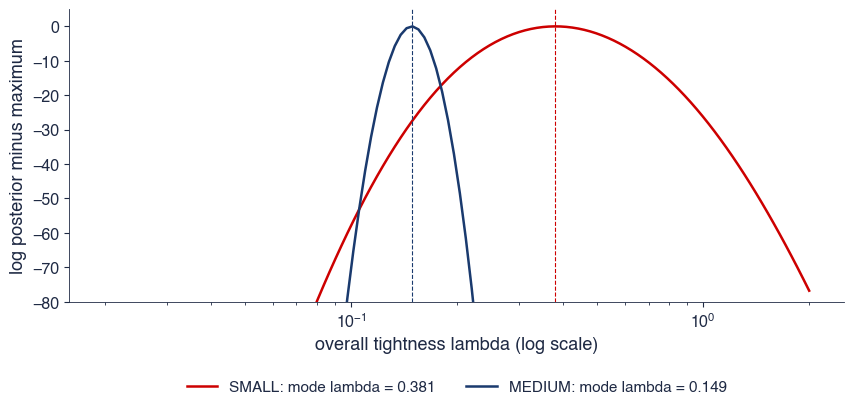

{'SMALL': {'lam': 0.380822714078308, 'mu': 0.19931643407888758, 'phi': 0.4396762772033556, 'logpost': -210.7425029810901, 'n': 3, 'k': 40, 'T': 707, 'own_cpi': 0.9999420685575683, 'own_cpi_ols': np.float64(0.9979876746987693), 'lp_02': -12.613392752909846, 'lp_1': -26.292414874546495}, 'MEDIUM': {'lam': 0.14891580030557963, 'mu': 0.1337942631342278, 'phi': 0.4449495271410635, 'logpost': -10412.730586126874, 'n': 20, 'k': 261, 'T': 707, 'own_cpi': 1.0000027513049272, 'own_cpi_ols': None, 'lp_02': -42.57122762828476, 'lp_1': -2173.522353914641}, 'bgr': {'target': 0.4347517811123371, 'MEDIUM': 0.1577388601569243, 'LARGE': 0.058758758454038426}}


In [15]:
# Solution
print(b1_glp(save_it=False))

**Interpretation of the result.** The larger system needs a tighter prior; small $\mu$ and $\phi$ favour persistence.

## B2 [Proposed]: a Bayesian VAR for Romania

**Question.** Does a GLP-type BVAR forecast Romanian inflation and industrial production better than a random walk and an OLS VAR(12)? Model: B1.

1. GLP mode on the full sample.
2. Recursive forecasts 2015–2025, 1 and 12 months.
3. RMSE table and the range of $\lambda$.
4. Interpretation: what does the OLS VAR teach?

**Report:** one set of hyperparameters, a table of 12 RMSEs, one interval, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: factors of the FRED-MD panel on three samples

**Question.** Is the factor structure of the US economy stable over time?

1. Eight EM factors on 1960–1984, 1985–2007, 2008–2026.
2. Bai–Ng choices and variance shares.
3. Correlations of the first factor.
4. Interpretation: what changed?

**Report:** a table of three rows and seven columns, one sentence.

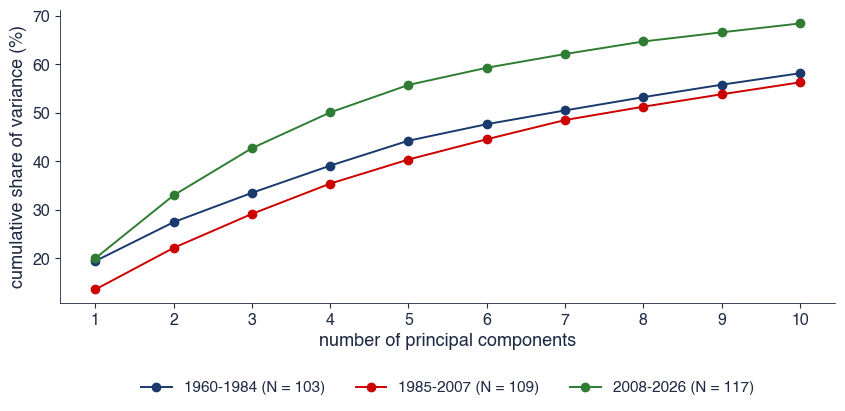

{'1960-1984': {'N': 103, 'T': 300, 'k': {'IC_p1': 6, 'IC_p2': 6, 'IC_p3': 12, 'PC_p1': 10, 'PC_p2': 10}, 'share': [0.19447113077819608, 0.08020616575205322, 0.06036800967999913, 0.05609016012104663, 0.05140634302395534], 'cum3': 0.3350453062102484, 'cor': {'INDPRO': 0.8520318124708389, 'PAYEMS': 0.8541890589229788, 'CPIAUCSL': 0.10224674105892811, 'FEDFUNDS': 0.40131818027146166}}, '1985-2007': {'N': 109, 'T': 276, 'k': {'IC_p1': 7, 'IC_p2': 7, 'IC_p3': 12, 'PC_p1': 11, 'PC_p2': 10}, 'share': [0.13587837500939406, 0.08576596260908076, 0.06995071439811466, 0.06251576831675254, 0.04963710348712983], 'cum3': 0.2915950520165895, 'cor': {'INDPRO': 0.7736433486974396, 'PAYEMS': 0.7698019692652195, 'CPIAUCSL': 0.009810608705769283, 'FEDFUNDS': 0.538676253728532}}, '2008-2026': {'N': 117, 'T': 223, 'k': {'IC_p1': 8, 'IC_p2': 8, 'IC_p3': 12, 'PC_p1': 11, 'PC_p2': 10}, 'share': [0.20021982538374145, 0.1297471155093807, 0.09712464414348379, 0.07374814547220757, 0.05660663491036151], 'cum3': 0.427

In [17]:
# Solution
print(b3_factor_samples(save_it=False))

**Interpretation of the result.** The first factor is real activity in all periods; it explains least in 1985–2007.

## B4 [Proposed]: FAVAR and the number of factors

**Question.** Do the FAVAR responses depend on $K$? Model: B3.

1. Estimate with $K = 1, 3, 5$.
2. Report the IP trough, the CPI responses and the unemployment peak.
3. Interpretation: which $K$ would you report?

**Report:** a table of three rows and five columns, two sentences.

In [ ]:
# Your code here


## B5 [Solved]: nowcasting Romanian GDP in 2026Q2

**Question.** How did the AR, bridge and MIDAS nowcasts of 2026Q2 evolve, and how accurate are they in general?

1. Information sets at the ends of April–July 2026.
2. Nowcasts at each date.
3. RMSE 2013–2026 without 2020Q2–Q3.
4. Interpretation: is one quarter enough to rank models?

**Report:** two tables, one sentence.

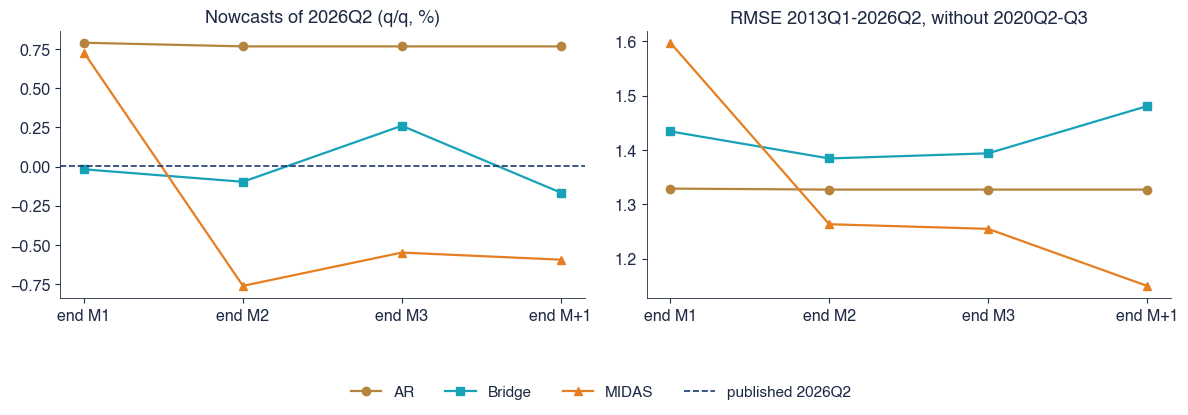

{'nowcasts': {'M1': {'AR': 0.7911456762066327, 'Bridge': -0.017945102312432487, 'MIDAS': 0.7272524077884306}, 'M2': {'AR': 0.767837192343227, 'Bridge': -0.09755323161686277, 'MIDAS': -0.7628096806483953}, 'M3': {'AR': 0.767837192343227, 'Bridge': 0.26048024682802223, 'MIDAS': -0.5499275669275399}, 'M+1': {'AR': 0.767837192343227, 'Bridge': -0.16664191460269792, 'MIDAS': -0.5954222846063555}}, 'actual': 0.00048382765722720933, 'rmse': {'AR|M+1': 1.3269867729525737, 'AR|M1': 1.3287922506936805, 'AR|M2': 1.3269867729525737, 'AR|M3': 1.3269867729525737, 'Bridge|M+1': 1.480597526562816, 'Bridge|M1': 1.4341238606750675, 'Bridge|M2': 1.3843207996763425, 'Bridge|M3': 1.3937444550652907, 'MIDAS|M+1': 1.149718652047752, 'MIDAS|M1': 1.5973782082076038, 'MIDAS|M2': 1.2631973979124578, 'MIDAS|M3': 1.2546735353230634}}


In [19]:
# Solution
print(b5_nowcast_q2(save_it=False))

**Interpretation of the result.** One quarter says almost nothing about a ranking; over 2013–2026 MIDAS is best late in the quarter.

## B6 [Proposed]: the 2026Q3 nowcast and its news

**Question.** How did the September 2026 releases change the DFM nowcast of 2026Q3? Model: B5.

1. Estimate on the August information set.
2. News decomposition with fixed parameters.
3. Check the sum; compare with EM.
4. Interpretation: hard or soft data?

**Report:** two nowcasts, a table of impacts, one check, two EM numbers, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: do surveys still help after 2020?

**Question.** Do the six confidence balances improve the end-of-quarter DFM nowcast beyond hard data, before and after 2020? Model: B5.

1. A five-line pre-registration.
2. RMSE of both DFMs and the AR on each subsample.
3. Interpretation: what can and cannot be concluded?

**Report:** a five-line plan, a table of six RMSEs, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) with the Minnesota prior, lambda = 0 gives the OLS estimates;
- (b) the natural conjugate prior allows a cross-variable shrinkage theta below 1;
- (c) in large BVARs the optimal lambda increases with the number of variables;
- (d) the sum-of-coefficients prior pushes the VAR towards a model in first differences;
- (e) Bai–Ng IC_p2 picks the number of factors that maximises the explained variance;
- (f) the news of a release is its value; its impact is the value times the loading;
- (g) a Gibbs sampler with R-hat = 1.56 has converged.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
